In [12]:
#Wczytanie danych z maja 2023 roku do osobnych data frameów
import pandas as pd
df1 = pd.read_csv("C:\\Users\\kacpe\\OneDrive\\Dokumenty\\APolitechnika\\Projekty\\Projekt_koncowy_PDU\\202305-citibike-tripdata_1.csv")
df2 = pd.read_csv("C:\\Users\\kacpe\\OneDrive\\Dokumenty\\APolitechnika\\Projekty\\Projekt_koncowy_PDU\\202305-citibike-tripdata_2.csv")
df3 = pd.read_csv("C:\\Users\\kacpe\\OneDrive\\Dokumenty\\APolitechnika\\Projekty\\Projekt_koncowy_PDU\\202305-citibike-tripdata_3.csv")
df4 = pd.read_csv("C:\\Users\\kacpe\\OneDrive\\Dokumenty\\APolitechnika\\Projekty\\Projekt_koncowy_PDU\\202305-citibike-tripdata_4.csv")
print(df3.head())

C:\Users\kacpe\AppData\Local\Temp\ipykernel_17116\1505956932.py:3: DtypeWarning: Columns (0: end_station_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv("C:\\Users\\kacpe\\OneDrive\\Dokumenty\\APolitechnika\\Projekty\\Projekt_koncowy_PDU\\202305-citibike-tripdata_1.csv")


KeyboardInterrupt: 

In [5]:
#Łączenie data frameów w jeden
df = pd.concat([df1, df2, df3, df4], ignore_index=True)
print(df.head())

            ride_id  rideable_type               started_at  \
0  6F58ECF40A603F36  electric_bike  2023-05-02 16:28:41.650   
1  BE3FA50CE9E524FB   classic_bike  2023-05-14 19:06:57.691   
2  F5798F3F66BA8361  electric_bike  2023-05-03 11:20:28.068   
3  22A4FDB4999C3B7C   classic_bike  2023-05-11 15:39:41.745   
4  9C03BD4F16AE2150  electric_bike  2023-05-07 10:37:38.685   

                  ended_at         start_station_name start_station_id  \
0  2023-05-02 16:44:51.560            6 Ave & W 34 St           6364.1   
1  2023-05-14 19:23:55.927            1 Ave & E 62 St          6753.08   
2  2023-05-03 11:34:34.715  Kenmare St & Elizabeth St          5453.06   
3  2023-05-11 16:04:31.799     Riverside Dr & W 91 St          7524.16   
4  2023-05-07 10:53:00.291  Cathedral Pkwy & Broadway          7680.03   

            end_station_name end_station_id  start_lat  start_lng    end_lat  \
0         E 84 St & Park Ave        7243.04  40.749640 -73.988050  40.778627   
1         E 84 S

In [7]:
#Teraz chciałbym w 2 nowych kolumnach mieć godzinę oraz dzień tygodnia
#Upewniamy się czy pandas widzi daty jako daty a nie stringi
print(df.dtypes)
#Okazuje się że jako stringi, zatem konwertujemy je na daty, zmieniamy godzinę na Amerykańską
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at'] = pd.to_datetime(df['ended_at'])
#Sprawdźmy czy się udało - tak, jak widzać poniżej
print(df.dtypes)

ride_id                   str
rideable_type             str
started_at                str
ended_at                  str
start_station_name        str
start_station_id       object
end_station_name          str
end_station_id         object
start_lat             float64
start_lng             float64
end_lat               float64
end_lng               float64
member_casual             str
dtype: object
ride_id                          str
rideable_type                    str
started_at            datetime64[us]
ended_at              datetime64[us]
start_station_name               str
start_station_id              object
end_station_name                 str
end_station_id                object
start_lat                    float64
start_lng                    float64
end_lat                      float64
end_lng                      float64
member_casual                    str
dtype: object


In [8]:
#Teraz możemy stworzyć nowe kolumny z godziną i dniem tygodnia
df['hour'] = df['started_at'].dt.hour
df['day_of_week'] = df['started_at'].dt.day_name()
#Jak widać poniżej, udało się
print(df.head())

            ride_id  rideable_type              started_at  \
0  6F58ECF40A603F36  electric_bike 2023-05-02 16:28:41.650   
1  BE3FA50CE9E524FB   classic_bike 2023-05-14 19:06:57.691   
2  F5798F3F66BA8361  electric_bike 2023-05-03 11:20:28.068   
3  22A4FDB4999C3B7C   classic_bike 2023-05-11 15:39:41.745   
4  9C03BD4F16AE2150  electric_bike 2023-05-07 10:37:38.685   

                 ended_at         start_station_name start_station_id  \
0 2023-05-02 16:44:51.560            6 Ave & W 34 St           6364.1   
1 2023-05-14 19:23:55.927            1 Ave & E 62 St          6753.08   
2 2023-05-03 11:34:34.715  Kenmare St & Elizabeth St          5453.06   
3 2023-05-11 16:04:31.799     Riverside Dr & W 91 St          7524.16   
4 2023-05-07 10:53:00.291  Cathedral Pkwy & Broadway          7680.03   

            end_station_name end_station_id  start_lat  start_lng    end_lat  \
0         E 84 St & Park Ave        7243.04  40.749640 -73.988050  40.778627   
1         E 84 St & Park Ave

In [10]:
#W następnych krokach będziemy tworzyć macierz pod heatmapę, stwórzmy słowniki dla dni, by łatwiej za ich pomocą indeksować po macierzy
#Dla dni tygodnia :
day_dictionary = {
    'Monday': 0,
    'Tuesday': 1,
    'Wednesday': 2,
    'Thursday': 3,
    'Friday': 4,
    'Saturday': 5,
    'Sunday': 6
}
print(day_dictionary)

{'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3, 'Friday': 4, 'Saturday': 5, 'Sunday': 6}
0


In [13]:
#Utworzymy teraz mapę pod heat-mapę o wymiarach liczba dni tygodnia na liczba godzin, czyli 7x24
import numpy as np
heat_map_matrix = np.zeros((7, 24))
#Teraz iterujemy po data frameie i zliczamy ilość wypożyczeń dla każdej kombinacji
for i in range(df.shape[0]):
    row = df.iloc[i]
    day = row['day_of_week']
    hour = row['hour']
    heat_map_matrix[day_dictionary[day], hour] += 1
print(heat_map_matrix)


[[ 4769.  2762.  1702.  1092.  1324.  3753. 10652. 23074. 33132. 25763.
  21932. 24143. 28227. 30337. 34497. 39216. 43777. 55601. 53197. 40197.
  27246. 18531. 13647.  8640.]
 [ 4814.  2458.  1454.   857.  1199.  4722. 13806. 27606. 41592. 29619.
  20050. 21476. 24200. 26736. 31434. 36670. 42571. 59320. 56124. 41383.
  28311. 19389. 14984.  9292.]
 [ 4956.  2693.  1489.   965.  1177.  4654. 14067. 30712. 44400. 31923.
  22726. 23500. 26855. 29076. 33146. 37794. 44078. 61126. 56430. 37663.
  25485. 18275. 15009.  9402.]
 [ 4302.  2123.  1253.   828.   937.  3356.  9984. 21488. 32247. 24222.
  17585. 17345. 19976. 22361. 26530. 30130. 34667. 47081. 45192. 33230.
  23118. 16485. 13254.  9253.]
 [ 5492.  3231.  1937.  1206.  1115.  3219.  9259. 20213. 28188. 22858.
  19556. 21960. 25606. 28198. 32249. 35880. 39175. 44336. 40806. 31975.
  22366. 16312. 14394. 12397.]
 [ 9166.  6724.  4417.  2641.  1646.  1869.  3498.  6530. 11617. 16833.
  20956. 25513. 28169. 29134. 29512. 29632. 29695. 28

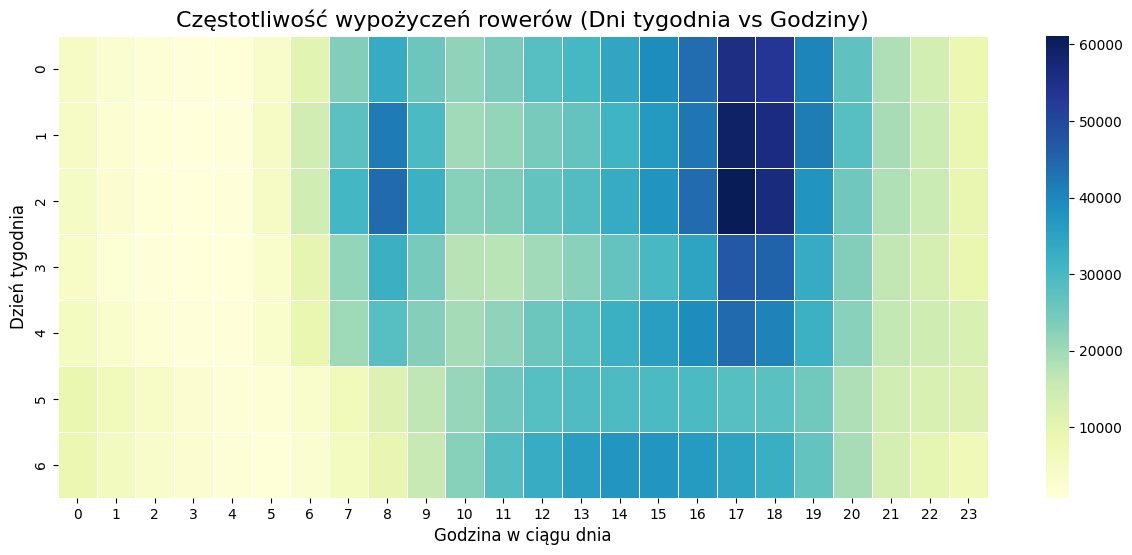

In [14]:
#Teraz możemy stworzyć heat-mapę
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(15, 6))

# 2. Rysowanie heatmapy
sns.heatmap(heat_map_matrix,
            cmap='YlGnBu',       # Paleta kolorów: od żółtego (mało) do ciemnoniebieskiego (dużo)
            annot=False,         # Zmień na True, jeśli chcesz wpisać konkretne liczby w kwadraciki
            fmt='g',             # Format wyświetlania liczb (jeśli annot=True)
            linewidths=0.5)      # Delikatne linie siatki między kwadracikami

# 3. Dodanie podpisów
plt.title('Częstotliwość wypożyczeń rowerów (Dni tygodnia vs Godziny)', fontsize=16)
plt.xlabel('Godzina w ciągu dnia', fontsize=12)
plt.ylabel('Dzień tygodnia', fontsize=12)

# 4. Wyświetlenie wykresu
plt.show()